In [1]:
import torch 
import os
import pandas as pd
import pickle
import loompy

In [2]:
# load in boundary distances 
embs = pd.read_csv("/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_bound.csv")
print(embs['boundary_distance'].head(10))
print(embs['stimulation'].head(10))
print(len(embs['stimulation']))


0   -0.415800
1   -0.195274
2   -0.284387
3   -0.385035
4   -0.506675
5   -0.385726
6    0.007204
7   -0.590978
8   -0.378580
9    0.352616
Name: boundary_distance, dtype: float64
0    rest
1     act
2    rest
3    rest
4    rest
5     act
6    rest
7    rest
8     act
9    rest
Name: stimulation, dtype: object
47726


In [4]:
# load in attention rankings 
attention_weights_path = "/u/scratch/r/ramadas/geneformer_models_res/gene_rankings5000.pkl"
with open(attention_weights_path, 'rb') as f:
    gene_rankings = pickle.load(f)

# Print rankings for first few cells
num_cells_to_show = 3  # Adjust as needed
for i in range(min(num_cells_to_show, len(gene_rankings))):
    cell = gene_rankings[i]
    print(f"\nCell {cell['cell_id']} ({cell['label']}):")
    print(cell['rankings'].head(10))  # Show top 10 genes


Cell 0 (Quiescent):
              Gene  Attention Score
0  ENSG00000104964         7.614909
1  ENSG00000005007         6.423832
2  ENSG00000143612         6.361800
3  ENSG00000100401         6.348027
4  ENSG00000008988         6.039608
5  ENSG00000165650         5.902912
6  ENSG00000151023         5.655440
7  ENSG00000115963         5.594286
8  ENSG00000112981         5.255274
9  ENSG00000110057         5.242654

Cell 1 (Proliferating):
              Gene  Attention Score
0  ENSG00000165732        53.808666
1  ENSG00000111640        33.136925
2  ENSG00000169288        32.059246
3  ENSG00000165650        31.518036
4  ENSG00000143977        29.889786
5  ENSG00000008394        29.331074
6  ENSG00000152056        29.199886
7  ENSG00000135269        28.509611
8  ENSG00000143612        28.383688
9  ENSG00000083312        27.187346

Cell 2 (Quiescent):
              Gene  Attention Score
0  ENSG00000183741        48.322308
1  ENSG00000174943        39.912895
2  ENSG00000165650        33.9502

In [5]:
# Convert pkl files to dataframes to concat
rankings_df = pd.DataFrame([{'cell_id': item['cell_id'], 
                             'label': item['label'],
                             'top_genes': item['top_genes']} 
                           for item in gene_rankings])

# Join on shared column name
merged_data = pd.merge(embs, rankings_df, on='cell_id', how='inner')

# Bin by boundary distance
print("Boundary distance range:", merged_data['boundary_distance'].min(), 
      "to", merged_data['boundary_distance'].max())
merged_data['distance_bin'] = pd.cut(merged_data['boundary_distance'], 
                                     bins=5, labels=['bin1', 'bin2', 'bin3', 'bin4', 'bin5'])
print(len(merged_data['stimulation']))
# Now you can analyze gene rankings per bin
for bin_name, bin_data in merged_data.groupby('distance_bin'):
    print(f"\nAnalyzing bin: {bin_name}")
    print(f"Number of cells: {len(bin_data)}")
    print(f"Distance range: {bin_data['boundary_distance'].min():.4f} to {bin_data['boundary_distance'].max():.4f}")
    print(f"Average distance: {bin_data['boundary_distance'].mean():.4f}")



Boundary distance range: -0.7536365480697566 to 0.7075635267619214
1000

Analyzing bin: bin1
Number of cells: 448
Distance range: -0.7536 to -0.4615
Average distance: -0.5106

Analyzing bin: bin2
Number of cells: 397
Distance range: -0.4612 to -0.1704
Average distance: -0.4075

Analyzing bin: bin3
Number of cells: 58
Distance range: -0.1684 to 0.1215
Average distance: -0.0442

Analyzing bin: bin4
Number of cells: 53
Distance range: 0.1310 to 0.4136
Average distance: 0.2881

Analyzing bin: bin5
Number of cells: 44
Distance range: 0.4196 to 0.7076
Average distance: 0.4883


/tmp/ipykernel_97401/1938658277.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, bin_data in merged_data.groupby('distance_bin'):


In [15]:
def aggregate_top_genes_by_bin(merged_data, top_n=25, max_weight = 10):
    """
    Aggregate gene rankings across cells in each distance bin using a voting system.
    
    Args:
        merged_data: DataFrame with 'distance_bin' and 'top_genes' columns
        top_n: Number of top genes to return per bin
        
    Returns:
        Dictionary mapping bin names to DataFrames of top genes with vote counts
    """
    bin_rankings = {}
    
    # Process each bin separately
    for bin_name, bin_data in merged_data.groupby('distance_bin'):
        # Count votes for each gene
        gene_votes = {}
        total_cells = len(bin_data)
        
        # Collect votes from each cell in this bin
        for _, cell in bin_data.iterrows():
            # Each gene in a cell's top_genes list gets a ranked style vote
            top_genes = cell['top_genes']
            
            for rank, gene in enumerate(top_genes):
                weight = max(max_weight - rank,1)
    
                if gene not in gene_votes:
                    gene_votes[gene] = 0
                gene_votes[gene] += weight
                
        
        # Convert to DataFrame for easier sorting and analysis
        vote_df = pd.DataFrame({
            'gene': list(gene_votes.keys()),
            'votes': list(gene_votes.values()),
            'percentage': [score/(total_cells * max_weight) * 100 for score in gene_votes.values()]
        })
        
        # Sort by votes (descending) and take top N
        vote_df = vote_df.sort_values('votes', ascending=False).reset_index(drop=True)
        bin_rankings[bin_name] = vote_df.head(top_n)
        
        print(f"\nTop genes in {bin_name} (distance range: {bin_data['boundary_distance'].min():.4f} to {bin_data['boundary_distance'].max():.4f}):")
        print(f"Total cells in bin: {total_cells}")
        print(vote_df.head(top_n)[['gene', 'votes', 'percentage']].to_string(index=False))
    
    return bin_rankings

bin_ranked = aggregate_top_genes_by_bin(merged_data)
# Percentage is defined as if gene appeared at top of rankings everytime it would be 100%


Top genes in bin1 (distance range: -0.7536 to -0.4615):
Total cells in bin: 448
           gene  votes  percentage
ENSG00000165650   3012   67.232143
ENSG00000008988   1951   43.549107
ENSG00000111716   1842   41.116071
ENSG00000115165   1087   24.263393
ENSG00000089248   1009   22.522321
ENSG00000087191    943   21.049107
ENSG00000248333    611   13.638393
ENSG00000132424    503   11.227679
ENSG00000159445    419    9.352679
ENSG00000104964    383    8.549107
ENSG00000084093    318    7.098214
ENSG00000115415    316    7.053571
ENSG00000149761    298    6.651786
ENSG00000166949    294    6.562500
ENSG00000149932    243    5.424107
ENSG00000131507    237    5.290179
ENSG00000078304    205    4.575893
ENSG00000142546    199    4.441964
ENSG00000183978    196    4.375000
ENSG00000115687    179    3.995536
ENSG00000100387    177    3.950893
ENSG00000115073    174    3.883929
ENSG00000175215    163    3.638393
ENSG00000175376    161    3.593750
ENSG00000124120    158    3.526786

Top gene

/tmp/ipykernel_27127/3800347038.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, bin_data in merged_data.groupby('distance_bin'):


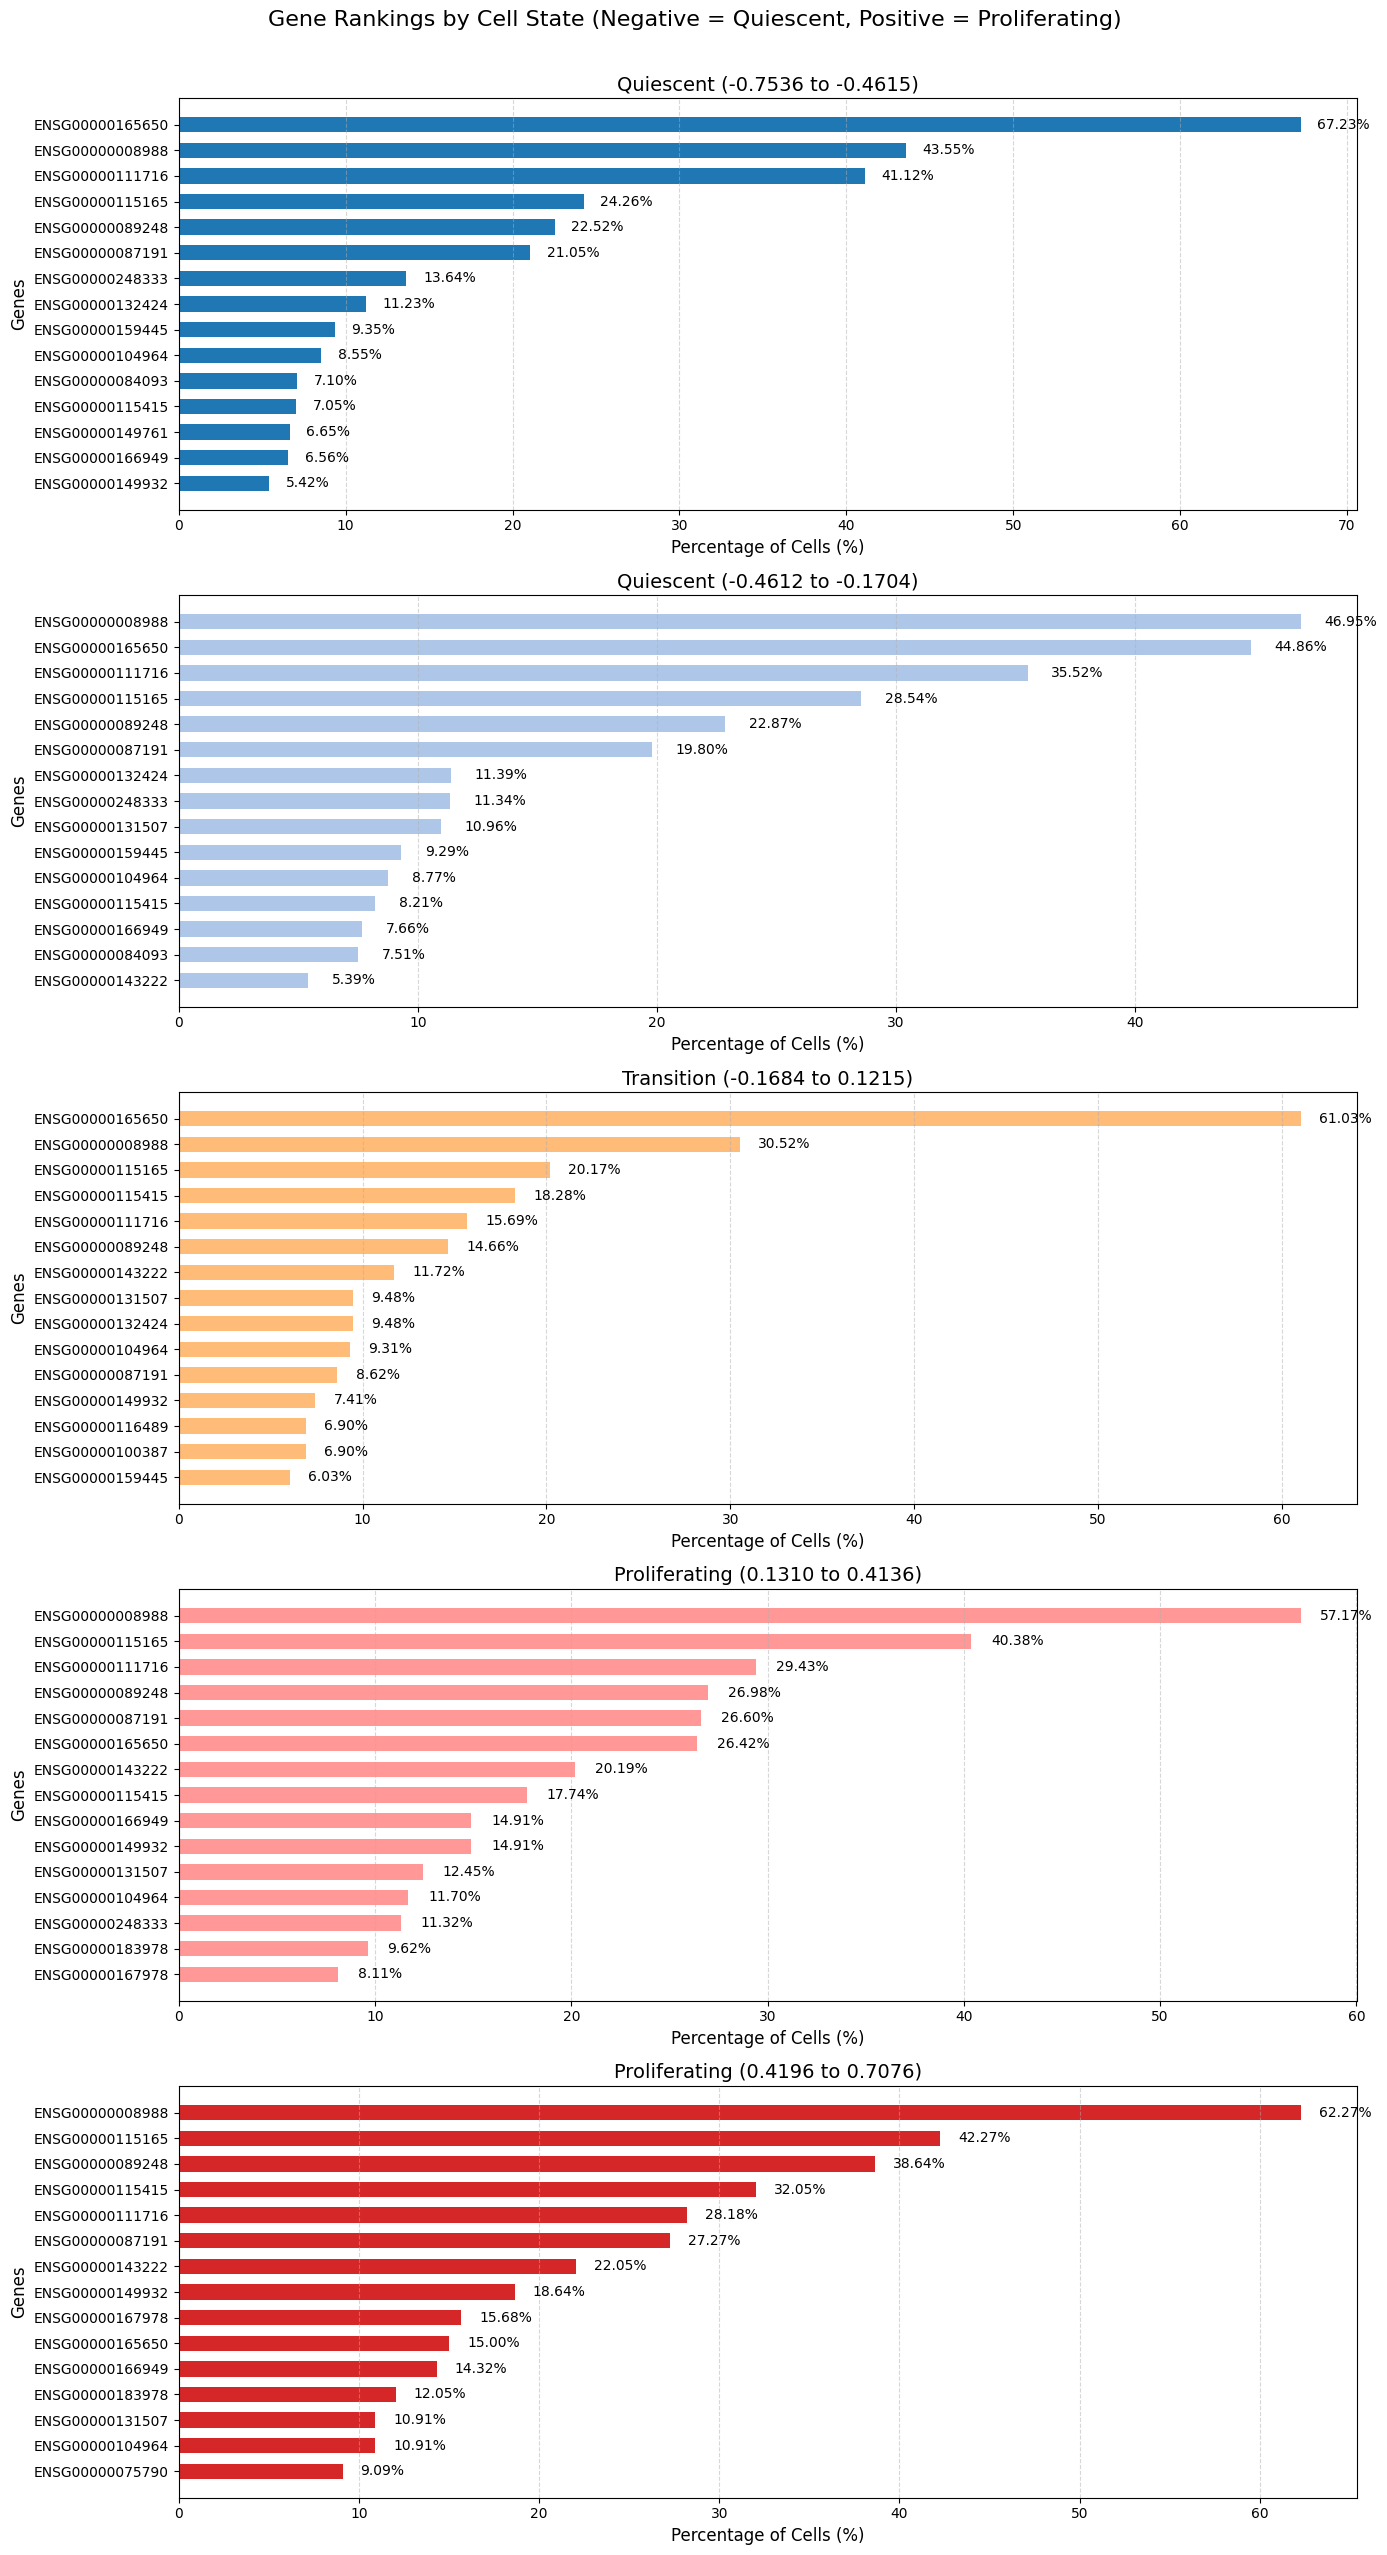

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def plot_bin_rankings_separated(bin_ranked, output_file=None, top_n=15):
    """
    Plot gene rankings for each bin separately, with genes ordered by percentage within each bin.
    
    Parameters:
    -----------
    bin_ranked : dict
        Dictionary mapping bin names to DataFrames with 'gene', 'votes', 'percentage' columns
    output_file : str, optional
        File path to save the plot
    top_n : int, optional
        Number of top genes to display for each bin
    """
    # Define a color palette with meaningful names
    bin_colors = {
        'bin1': '#1f77b4',  # Dark blue - most quiescent
        'bin2': '#aec7e8',  # Light blue - somewhat quiescent
        'bin3': '#ffbb78',  # Light orange - transitional
        'bin4': '#ff9896',  # Light red - somewhat proliferating
        'bin5': '#d62728',  # Dark red - most proliferating
    }
    
    # Define bin ranges and descriptions
    bin_descriptions = {
        'bin1': 'Quiescent (-0.7536 to -0.4615)',
        'bin2': 'Quiescent (-0.4612 to -0.1704)', 
        'bin3': 'Transition (-0.1684 to 0.1215)',
        'bin4': 'Proliferating (0.1310 to 0.4136)',
        'bin5': 'Proliferating (0.4196 to 0.7076)'
    }
    
   
    n_bins = len(bin_ranked)
    
    # Create a figure with subplots (one row per bin)
    fig, axes = plt.subplots(nrows=n_bins, figsize=(14, 5*n_bins))
    
    # Process each bin separately
    for i, (bin_name, bin_df) in enumerate(sorted(bin_ranked.items())):
        ax = axes[i]
        
        # Take top N genes and sort by percentage (descending)
        plot_df = bin_df.head(top_n).sort_values('percentage', ascending=True)
        
        # Create horizontal bar chart for this bin
        bars = ax.barh(y=range(len(plot_df)), width=plot_df['percentage'], 
                       color=bin_colors.get(bin_name, 'skyblue'), 
                       height=0.6)
        
        for j, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width + 1, j, f'{width:.2f}%', va='center', fontsize=10)
        
    
        ax.set_title(f'{bin_descriptions.get(bin_name, bin_name)}', fontsize=14)
        ax.set_xlabel('% of Cells with Gene in Top Rankings', fontsize=12)
        ax.set_ylabel('Genes', fontsize=12)
        
        # Set custom y-tick labels (gene names)
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['gene'], fontsize=10)
        
        # Add grid
        ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Adjust spacing between subplots
    plt.tight_layout()
    
    # Add a master title
    plt.suptitle('Gene Rankings by Cell State (Negative = Quiescent, Positive = Proliferating)', 
                fontsize=16, y=1.02)
    
    # Save if output file provided
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")
    
    plt.show()


plot_bin_rankings_separated(bin_ranked, top_n=15)